# Small data and deep learning
This pratical session proposes to study several techniques to improve training performance in the challenging context where few data and resources are available.

# Introduction
Assume we are in a context where few "gold" labeled data are available for training, say $\mathcal{X}_{\text{train}}\triangleq\{(x_n,y_n)\}_{n\leq N_{\text{train}}}$, where $N_{\text{train}}$ is small. A large test set $\mathcal{X}_{\text{test}}$ is available. A large amount of unlabeled data, $\mathcal{X}_{\text{nolabel}}$, is available. We also assume that we have a limited computational budget (e.g., no GPUs).

For each question, write a commented *Code* or a complete answer as a *Markdown*. When the objective of a question is to report a CNN accuracy, please use the following format to report it, at the end of the question :


| Model | Number of  epochs  | Train accuracy | Test accuracy |
|------|------|------|------|
|   XXX  | XXX | XXX | XXX |


If applicable, please add the field corresponding to the  __Accuracy on Full Data__ as well as a link to the __Reference paper__ you used to report those numbers. (You do not need to train a CNN on the full CIFAR10 dataset.)

In your final report, please keep the logs of each training procedure you used. We will only run this jupyter if we have some doubts on your implementation. 

__The total file sizes should be reasonable (feasible with 2MB only!). You will be asked to hand in the notebook, together with any necessary files required to run it if any.__


To run your experiments, you can use the same local installation as for previous TPs, or otherwise https://colab.research.google.com/.

## Training set creation
__Question 1 (2 points) :__ Propose a dataloader that will only use the first 100 samples of the CIFAR-10 training set. 

*Hint* : You can modify the file located at https://github.com/pytorch/vision/blob/master/torchvision/datasets/cifar.py or use the information from https://pytorch.org/vision/stable/datasets.html

This is our dataset $\mathcal{X}_{\text{train}}$, it will be used until the end of this project. The remaining samples correspond to $\mathcal{X}_{\text{nolabel}}$. The testing set $\mathcal{X}_{\text{test}}$ corresponds to the whole testing set of CIFAR-10.

In [1]:
# We add pytorch-lightning for its convenient seed everything function
!pip install pytorch-lightning

In [2]:
import os
import shutil

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score
from pytorch_lightning.utilities.seed import seed_everything
import torch, torchvision
from torch import optim
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm

In [3]:
seed_everything(1996)

Global seed set to 1996


1996

In [4]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

In [5]:
def get_dataloaders(train_transforms, test_transforms):
    # All training CIFAR-10 dataset
    train_all = torchvision.datasets.CIFAR10(root="data", train=True, download=True, transform=train_transforms)
    test_dataset = torchvision.datasets.CIFAR10(root="data", train=False, download=True, transform=test_transforms)

    # Splitting the train dataset into the two sub datasets of interest
    train_idxs = np.arange(100)
    no_label_idxs = np.arange(100, len(train_all))
    train_dataset = torch.utils.data.Subset(train_all, train_idxs)
    no_label_dataset = torch.utils.data.Subset(train_all, no_label_idxs)

    # One data loader per dataset
    train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=10, shuffle=True)
    no_label_dataloader = torch.utils.data.DataLoader(no_label_dataset, batch_size=10, shuffle=True)
    test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=256, shuffle=False)

    return train_dataloader, no_label_dataloader, test_dataloader

In [6]:
# Basic data transform (tensor conversion + normalization)
basic_transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(), 
    # CIFAR-10 statistics
    torchvision.transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261)),
])

In [7]:
train_dataloader, no_label_dataloader, test_dataloader = get_dataloaders(basic_transform, basic_transform)

Files already downloaded and verified
Files already downloaded and verified


## Testing procedure
__Question 2 (1.5 points) :__ Explain why the evaluation of the training procedure is difficult. Propose several solutions.

Evaluating the training procedure is difficult because we have a tiny training dataset. The usual strategy of creating a validation split is not appropiate. Not only we'd reduce our training set but also the performance estimate on a even more tiny validation split would have high variance (i.e it'd depend on the particular split). Some solutions can be:

* K-Fold cross-validation: this is not so common in deep learning because of the computational overhead. Instead of training only one model, we need to train K of them and average the performance obtained while training over the k-1 folds and evaluating in the other k fold, while rotating this hold-out fold.

* Consider some metrics which don't require a label and can be evaluated over the unlabeled dataset (E.g the uncertainty in the predictions, the margin between the two most likely predictions, etc)

* Heavily augment the training data and use these augmented copies as a validation split. It's possble that this estimate of the performance might be too optimistic.

# Raw approach: the baseline

In this section, the goal is to train a CNN on $\mathcal{X}_{\text{train}}$ and compare its performance with reported numbers from the litterature. You will have to re-use and/or design a standard classification pipeline. You should optimize your pipeline to obtain the best performances (image size, data augmentation by flip, ...).

The key ingredients for training a CNN are the batch size, as well as the learning rate schedule, i.e. how to decrease the learning rate as a function of the number of epochs. A possible schedule is to start the learning rate at 0.1 and decreasing it every 30 epochs by 10. In case of divergence, reduce the learning rate. A potential batch size could be 10, yet this can be cross-validated.

You can get some baselines accuracies in this paper : http://openaccess.thecvf.com/content_cvpr_2018/papers/Keshari_Learning_Structure_and_CVPR_2018_paper.pdf. Obviously, it is a different context for those researchers who had access to GPUs.

## ResNet architectures

__Question 3 (4 points) :__ Write a classification pipeline for $\mathcal{X}_{\text{train}}$, train from scratch and evaluate a *ResNet-18* architecture specific to CIFAR10 (details about the ResNet-18 model, originally designed for the ImageNet dataset, can be found here: https://arxiv.org/abs/1512.03385). Please report the accuracy obtained on the whole dataset as well as the reference paper/GitHub link.

*Hint:* You can re-use the following code: https://github.com/kuangliu/pytorch-cifar. During a training of 10 epochs, a batch size of 10 and a learning rate of 0.01, one obtains 40% accuracy on $\mathcal{X}_{\text{train}}$ (\~2 minutes) and 20% accuracy on $\mathcal{X}_{\text{test}}$ (\~5 minutes).

In [8]:
# Extracted from https://github.com/kuangliu/pytorch-cifar/blob/master/models/resnet.py

'''ResNet in PyTorch.

For Pre-activation ResNet, see 'preact_resnet.py'.

Reference:
[1] Kaiming He, Xiangyu Zhang, Shaoqing Ren, Jian Sun
    Deep Residual Learning for Image Recognition. arXiv:1512.03385
'''

class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(
            in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion*planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion*planes,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion*planes)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out


class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, in_planes, planes, stride=1):
        super(Bottleneck, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.conv3 = nn.Conv2d(planes, self.expansion *
                               planes, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(self.expansion*planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion*planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion*planes,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion*planes)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = F.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out


class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(ResNet, self).__init__()
        self.in_planes = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)
        self.linear = nn.Linear(512*block.expansion, num_classes)

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_planes, planes, stride))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = F.avg_pool2d(out, 4)
        out = out.view(out.size(0), -1)
        out = self.linear(out)
        return out


def ResNet18():
    return ResNet(BasicBlock, [2, 2, 2, 2])


def ResNet34():
    return ResNet(BasicBlock, [3, 4, 6, 3])


def ResNet50():
    return ResNet(Bottleneck, [3, 4, 6, 3])


def ResNet101():
    return ResNet(Bottleneck, [3, 4, 23, 3])


def ResNet152():
    return ResNet(Bottleneck, [3, 8, 36, 3])


In [9]:
def train(model, objective, optimizer, train_dataloader, epochs, device, scheduler=None):
    """
    Complete training loop (without evaluation outside of training)
    """
    model.to(device)
    model.train()
    # Metrics to track during training process
    train_losses = []
    train_accuracies = []
    lrs = []
    for epoch in range(epochs):
        # Single step of training
        epoch_losses = []
        epoch_accuracies = []
        for data in tqdm(train_dataloader, total=len(train_dataloader)):
            images, labels = data
            images = images.to(device)
            labels = labels.to(device)
            logits = model(images)
            loss = objective(logits, labels)
            predictions = logits.argmax(dim=1)
            # Backprop
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_losses.append(loss.item())
            epoch_accuracies.append(accuracy_score(labels.cpu().numpy(), predictions.cpu().numpy()))
        # Adjust lr
        if scheduler is not None:
            scheduler.step()
        # Averaging metrics across all batches
        train_loss = np.array(epoch_losses).mean()
        train_losses.append(train_loss)
        train_accuracy = np.array(epoch_accuracies).mean()
        train_accuracies.append(train_accuracy)
        lrs.append(optimizer.state_dict()['param_groups'][0]['lr'])

        print(f"Epoch {epoch + 1} | Train loss: {train_loss} | Train acc: {train_accuracy}")

    return train_losses, train_accuracies, lrs

In [10]:
def test(model, objective, test_dataloader, device):
    """
    Final test step over all test dataset
    """
    epoch_test_losses = []
    epoch_test_accuracies = []
    for test_data in tqdm(test_dataloader, total=len(test_dataloader)):
        with torch.no_grad():
            images, labels = test_data
            images = images.to(device)
            labels = labels.to(device)
            model.eval()
            logits = model(images)
            test_loss = objective(logits, labels)
            predictions = logits.argmax(dim=1)
            epoch_test_losses.append(test_loss.cpu().numpy())
            epoch_test_accuracies.append(accuracy_score(labels.cpu().numpy(), predictions.cpu().numpy()))
    # Averaging metrics across all batches
    test_loss = np.array(epoch_test_losses).mean()
    test_accuracy = np.array(epoch_test_accuracies).mean()
    
    return test_loss, test_accuracy

### First baseline

* Adam with default parameters
* Batch size 10
* Epochs 10

100%|██████████| 10/10 [00:00<00:00, 15.82it/s]


Epoch 1 | Train loss: 3.002624034881592 | Train acc: 0.11000000000000001


100%|██████████| 10/10 [00:00<00:00, 18.66it/s]


Epoch 2 | Train loss: 2.1875354170799257 | Train acc: 0.26999999999999996


100%|██████████| 10/10 [00:00<00:00, 21.02it/s]


...

100%|██████████| 10/10 [00:00<00:00, 17.60it/s]


Epoch 10 | Train loss: 0.8770560622215271 | Train acc: 0.73

##########
Train acuracy:  0.73
##########



100%|██████████| 40/40 [00:06<00:00,  6.51it/s]


##########
Test acuracy:  0.21220703125
##########



Text(0.5, 0, 'Epochs')

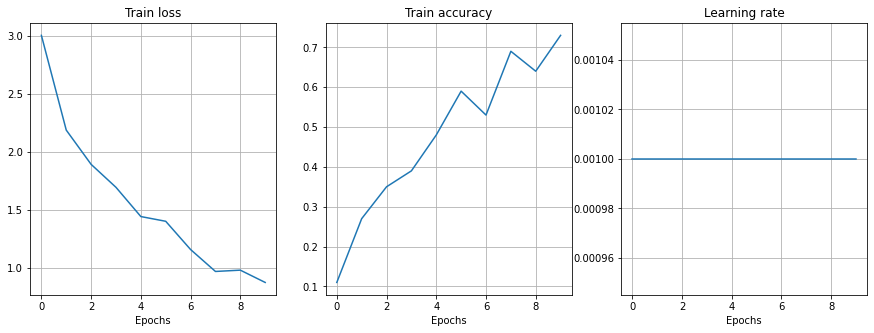

In [11]:
# Training settings
baseline = ResNet18()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline.parameters())

# Training the model
train_losses, train_accuracies, lrs = train(baseline, criterion, optimizer, train_dataloader, 10, device)
print("\n##########")
print("Train acuracy: ", train_accuracies[-1])
print("##########\n")

# Evaluation
test_loss, test_accuracy = test(baseline, criterion, test_dataloader, device)
print("\n##########")
print("Test acuracy: ", test_accuracy)
print("##########\n")

# Plots
plt.figure(figsize=[15,5])
plt.subplot(131)
plt.plot(train_losses)
plt.title("Train loss")
plt.grid()
plt.xlabel("Epochs")

plt.subplot(132)
plt.plot(train_accuracies)
plt.title("Train accuracy")
plt.grid()
plt.xlabel("Epochs")

plt.subplot(133)
plt.plot(lrs)
plt.title("Learning rate")
plt.grid()
plt.xlabel("Epochs")

### Second baseline
More epochs + simple lr scheduler

100%|██████████| 10/10 [00:00<00:00, 31.99it/s]


Epoch 1 | Train loss: 3.006165862083435 | Train acc: 0.16999999999999998


100%|██████████| 10/10 [00:00<00:00, 31.80it/s]


Epoch 2 | Train loss: 2.4059555649757387 | Train acc: 0.17


100%|██████████| 10/10 [00:00<00:00, 32.15it/s]


...

100%|██████████| 10/10 [00:00<00:00, 31.81it/s]


Epoch 100 | Train loss: 0.008242212142795325 | Train acc: 1.0

##########
Train acuracy:  1.0
##########



100%|██████████| 40/40 [00:04<00:00,  8.23it/s]



##########
Test acuracy:  0.24072265625
##########



Text(0.5, 0, 'Epochs')

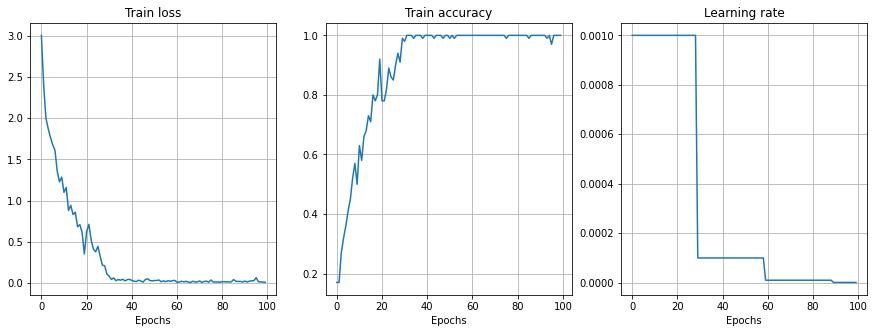

In [12]:
# Training settings
baseline_2 = ResNet18()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline_2.parameters())
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30)

# Training 
train_losses, train_accuracies, lrs = train(baseline_2, criterion, optimizer, train_dataloader, 100, device, scheduler)
print("\n##########")
print("Train acuracy: ", train_accuracies[-1])
print("##########\n")

# Evaluation
test_loss, test_accuracy = test(baseline_2, criterion, test_dataloader, device)
print("\n##########")
print("Test acuracy: ", test_accuracy)
print("##########\n")

# Plots
plt.figure(figsize=[15,5])
plt.subplot(131)
plt.plot(train_losses)
plt.title("Train loss")
plt.grid()
plt.xlabel("Epochs")

plt.subplot(132)
plt.plot(train_accuracies)
plt.title("Train accuracy")
plt.grid()
plt.xlabel("Epochs")

plt.subplot(133)
plt.plot(lrs)
plt.title("Learning rate")
plt.grid()
plt.xlabel("Epochs")

### Results

| Model | Number of  epochs  | Train accuracy | Test accuracy |
|------|------|------|------|
|  Resnet-18 baseline  | 10 | 0.73 | 0.21 |
|  Resnet-18 scheduler + more epochs  | 100 | 1.00 | 0.24 |

# Transfer learning

We propose to use pre-trained models on a classification task, in order to improve the results of our setting.

## ImageNet features

Now, we will use a model pre-trained on ImageNet and see how well it performs on CIFAR. A list of ImageNet pre-trained models is available on : https://pytorch.org/vision/stable/models.html

__Question 4 (3 points) :__ Pick a model from the list above, adapt it for CIFAR and retrain its final layer (or a block of layers, depending on the resources to which you have access to). Report its accuracy.

We use a Resnet-18 so the evaluation is "fair" respect to the previous question. 

We adapt the transforms to use the same normalization and ImageNet and test different image sizes (the original of CIFAR vs the original in ImageNet). We finally observe an important increase in performance when using the same sizes as used during pretraining in ImageNet.

In [13]:
# We adapt the normalization step to match Imagenet statistics

# Basic data transform (tensor conversion + normalization)
imagenet_transform_original_size = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(), 
    # ImageNet statistics
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
])

# Use the same image size as ImageNet
imagenet_transform_imagenet_size = torchvision.transforms.Compose([
    torchvision.transforms.Resize(224),           
    torchvision.transforms.ToTensor(), 
    # ImageNet statistics
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
])

# Image size as in CIFAR
pretrained_train, pretrained_no_label, pretrained_test = get_dataloaders(imagenet_transform_original_size, imagenet_transform_original_size)

# Image size as in ImageNet
pretrained_in_size_train, pretrained_in_size_no_label, pretrained_in_size_test = get_dataloaders(imagenet_transform_imagenet_size, imagenet_transform_imagenet_size)

Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified


### Resnet-18 with image size from CIFAR

100%|██████████| 10/10 [00:00<00:00, 94.79it/s]


Epoch 1 | Train loss: 4.905569219589234 | Train acc: 0.14


100%|██████████| 10/10 [00:00<00:00, 86.19it/s]


Epoch 2 | Train loss: 3.5502801895141602 | Train acc: 0.26999999999999996


100%|██████████| 10/10 [00:00<00:00, 92.80it/s]


...

100%|██████████| 10/10 [00:00<00:00, 100.17it/s]


Epoch 100 | Train loss: 0.3344983246177435 | Train acc: 0.93

##########
Train acuracy:  0.93
##########



100%|██████████| 40/40 [00:02<00:00, 13.46it/s]


##########
Test acuracy:  0.2353515625
##########



Text(0.5, 0, 'Epochs')

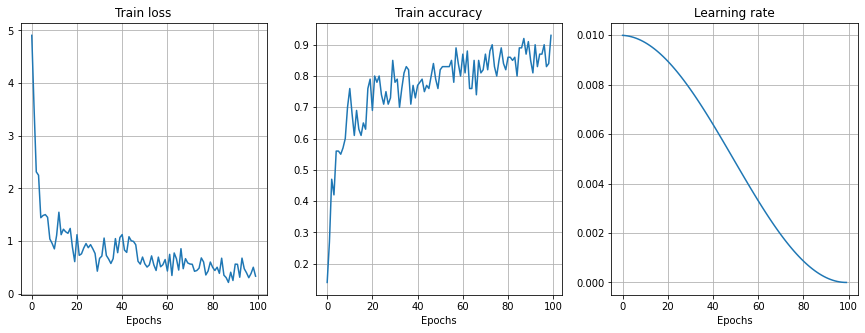

In [14]:
# Model definition
pretrained_1 = torchvision.models.resnet18(pretrained=True)
# Freezing the backbone
for param in pretrained_1.parameters():
    param.requires_grad = False
# Adapting final layer to predict 10 CIFAR-10 classes
pretrained_1.fc = nn.Linear(512, 10)

# Training settings
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(pretrained_1.parameters(), lr=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)

# Training
train_losses, train_accuracies, lrs = train(pretrained_1, criterion, optimizer, pretrained_train, 100, device, scheduler)
print("\n##########")
print("Train acuracy: ", train_accuracies[-1])
print("##########\n")

# Evaluation
test_loss, test_accuracy = test(pretrained_1, criterion, pretrained_test, device)
print("\n##########")
print("Test acuracy: ", test_accuracy)
print("##########\n")

# Plots
plt.figure(figsize=[15,5])
plt.subplot(131)
plt.plot(train_losses)
plt.title("Train loss")
plt.grid()
plt.xlabel("Epochs")

plt.subplot(132)
plt.plot(train_accuracies)
plt.title("Train accuracy")
plt.grid()
plt.xlabel("Epochs")

plt.subplot(133)
plt.plot(lrs)
plt.title("Learning rate")
plt.grid()
plt.xlabel("Epochs")

100%|██████████| 10/10 [00:00<00:00, 34.45it/s]


Epoch 1 | Train loss: 0.5145049318671227 | Train acc: 0.8400000000000001


100%|██████████| 10/10 [00:00<00:00, 44.76it/s]


Epoch 2 | Train loss: 0.3793652176856995 | Train acc: 0.8300000000000001


100%|██████████| 10/10 [00:00<00:00, 44.53it/s]


...

100%|██████████| 10/10 [00:00<00:00, 44.94it/s]


Epoch 100 | Train loss: 0.030410832202687744 | Train acc: 0.99

##########
Train acuracy:  0.99
##########



100%|██████████| 40/40 [00:02<00:00, 15.23it/s]


##########
Test acuracy:  0.26748046875
##########



Text(0.5, 0, 'Epochs')

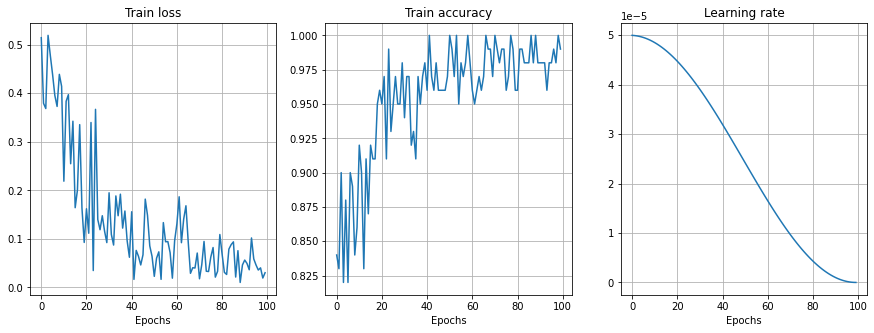

In [15]:
# Unfreeze the backbone
for param in pretrained_1.parameters():
    param.requires_grad = True

# Training settings
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(pretrained_1.parameters(), lr=5e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)

# Training
train_losses, train_accuracies, lrs = train(pretrained_1, criterion, optimizer, pretrained_train, 100, device, scheduler)
print("\n##########")
print("Train acuracy: ", train_accuracies[-1])
print("##########\n")

# Evaluation
test_loss, test_accuracy = test(pretrained_1, criterion, pretrained_test, device)
print("\n##########")
print("Test acuracy: ", test_accuracy)
print("##########\n")

# Plots
plt.figure(figsize=[15,5])
plt.subplot(131)
plt.plot(train_losses)
plt.title("Train loss")
plt.grid()
plt.xlabel("Epochs")

plt.subplot(132)
plt.plot(train_accuracies)
plt.title("Train accuracy")
plt.grid()
plt.xlabel("Epochs")

plt.subplot(133)
plt.plot(lrs)
plt.title("Learning rate")
plt.grid()
plt.xlabel("Epochs")

### Resnet-18 with image size from ImageNet

100%|██████████| 10/10 [00:00<00:00, 25.78it/s]


Epoch 1 | Train loss: 3.764407587051392 | Train acc: 0.13


100%|██████████| 10/10 [00:00<00:00, 28.08it/s]


Epoch 2 | Train loss: 1.9144819378852844 | Train acc: 0.45000000000000007


100%|██████████| 10/10 [00:00<00:00, 27.75it/s]


...

100%|██████████| 10/10 [00:00<00:00, 29.85it/s]


Epoch 100 | Train loss: 0.008849259372800589 | Train acc: 1.0

##########
Train acuracy:  1.0
##########



100%|██████████| 40/40 [00:30<00:00,  1.32it/s]


##########
Test acuracy:  0.51845703125
##########



Text(0.5, 0, 'Epochs')

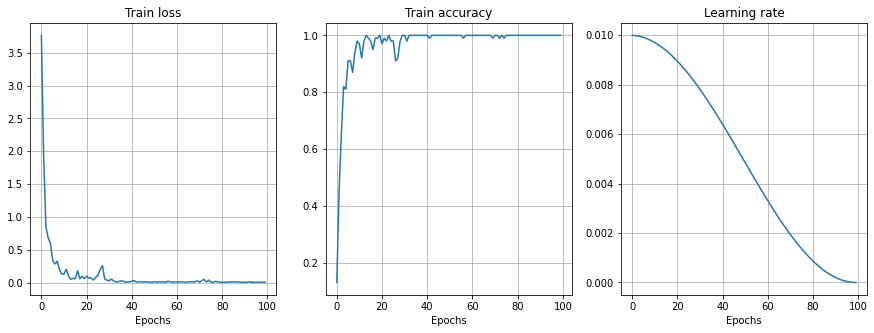

In [16]:
# Model definition
pretrained_2 = torchvision.models.resnet18(pretrained=True)
# Freezing the backbone
for param in pretrained_2.parameters():
    param.requires_grad = False
# Adapting final layer to predict 10 CIFAR-10 classes
pretrained_2.fc = nn.Linear(512, 10)

# Training settings
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(pretrained_2.parameters(), lr=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)

# Training
train_losses, train_accuracies, lrs = train(pretrained_2, criterion, optimizer, pretrained_in_size_train, 100, device, scheduler)
print("\n##########")
print("Train acuracy: ", train_accuracies[-1])
print("##########\n")

# Evaluation
test_loss, test_accuracy = test(pretrained_2, criterion, pretrained_in_size_test, device)
print("\n##########")
print("Test acuracy: ", test_accuracy)
print("##########\n")

# Plots
plt.figure(figsize=[15,5])
plt.subplot(131)
plt.plot(train_losses)
plt.title("Train loss")
plt.grid()
plt.xlabel("Epochs")

plt.subplot(132)
plt.plot(train_accuracies)
plt.title("Train accuracy")
plt.grid()
plt.xlabel("Epochs")

plt.subplot(133)
plt.plot(lrs)
plt.title("Learning rate")
plt.grid()
plt.xlabel("Epochs")

100%|██████████| 10/10 [00:00<00:00, 15.69it/s]


Epoch 1 | Train loss: 0.012732996337581426 | Train acc: 1.0


100%|██████████| 10/10 [00:00<00:00, 15.18it/s]


Epoch 2 | Train loss: 0.029110763623612 | Train acc: 0.99


100%|██████████| 10/10 [00:00<00:00, 15.57it/s]


...

100%|██████████| 10/10 [00:00<00:00, 15.43it/s]


Epoch 100 | Train loss: 0.0004451951453120273 | Train acc: 1.0

##########
Train acuracy:  1.0
##########



100%|██████████| 40/40 [00:34<00:00,  1.17it/s]


##########
Test acuracy:  0.5703125
##########



Text(0.5, 0, 'Epochs')

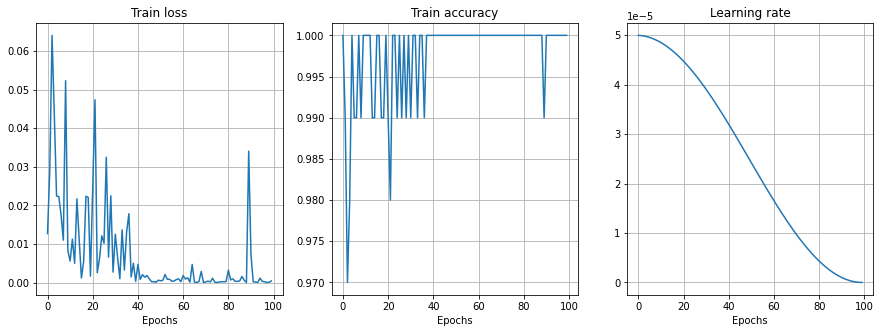

In [17]:
# Unfreeze the backbone
for param in pretrained_2.parameters():
    param.requires_grad = True

# Training settings
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(pretrained_2.parameters(), lr=5e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)

# Training
train_losses, train_accuracies, lrs = train(pretrained_2, criterion, optimizer, pretrained_in_size_train, 100, device, scheduler)
print("\n##########")
print("Train acuracy: ", train_accuracies[-1])
print("##########\n")

# Evaluation
test_loss, test_accuracy = test(pretrained_2, criterion, pretrained_in_size_test, device)
print("\n##########")
print("Test acuracy: ", test_accuracy)
print("##########\n")

# Plots
plt.figure(figsize=[15,5])
plt.subplot(131)
plt.plot(train_losses)
plt.title("Train loss")
plt.grid()
plt.xlabel("Epochs")

plt.subplot(132)
plt.plot(train_accuracies)
plt.title("Train accuracy")
plt.grid()
plt.xlabel("Epochs")

plt.subplot(133)
plt.plot(lrs)
plt.title("Learning rate")
plt.grid()
plt.xlabel("Epochs")

### Results

Full training = training only a linear layer first and then training the whole model

Linear training = training only a linear layer on top of the fixed backbone

| Model | Number of  epochs  | Train accuracy | Test accuracy |
|------|------|------|------|
|  Pretrained Resnet-18 (32 CIFAR image size, full training)  | 200 | 0.99 | 0.27 |
|  Pretrained Resnet-18 (224 ImageNet image size, full training)  | 200 | 1.00 | 0.57 |
|  Pretrained Resnet-18 (32 CIFAR image size, linear training)  | 100 | 0.93 | 0.24 |
|  Pretrained Resnet-18 (224 ImageNet image size, linear training)  | 100 | 1.00 | 0.52 |

# Incorporating priors
Geometrical priors are appealing for image classification tasks. 
A color image $x$ can be seen as a function: $\mathbb{S}\rightarrow\mathbb{R}^3$, where $\mathbb{S} \subset \mathbb{R}^2$ is the image support.
Let us consider transformations $\mathcal{T}$ of possible inputs $x$. For instance, if an image had infinite support, a translation $\mathcal{T}_a$ of an image $x$ by a shift $a$ would lead to a new infinite-support image $\mathcal{T}_a(x)$, described at each pixel $u$ by :

$$\forall u, \mathcal{T}_a(x)(u)=x(u-a)\,.$$

__Question 5 (1.5 points) :__ Explain the issues when dealing with translations, rotations, scaling effects, color changes on $32\times32$ images. Propose several ideas to tackle them.

Since images have finite support, when geometrically transforming the image we might end in regions where there is no image information. Some solutions are:

* Pad the image with different techniques such as a constant value, mirroring, etc
* Interpolate missing values in rotations
* Apply transformations in the frequency domain (via Fourier Transform) to avoid having to explicitly interpolate the data

## Data augmentations

__Question 6 (3 points) :__ Propose a set of geometric transformations beyond translation, and incorporate them in your training pipeline. Train the model of the __Question 3__ with them and report the accuracies.
You can use tools from https://pytorch.org/vision/stable/transforms.html 

In [18]:
from torchvision.transforms.transforms import RandomRotation

# Data augmentation transform (+ normalization) CIFAR size
data_augmentation_transform = torchvision.transforms.Compose(
    [
    torchvision.transforms.RandomResizedCrop(32, scale=(0.5, 1)),
    torchvision.transforms.RandomRotation(25),
    torchvision.transforms.RandomVerticalFlip(p=0.2),
    torchvision.transforms.RandomHorizontalFlip(p=0.5),
    torchvision.transforms.RandomApply(
        [torchvision.transforms.ColorJitter(brightness=0.4, contrast=0.4,
                                saturation=0.2, hue=0.1)],
        p=0.8
    ),
    torchvision.transforms.RandomGrayscale(p=0.2),
    torchvision.transforms.RandomSolarize(0.5,0.2),
    torchvision.transforms.ToTensor(), 

    # ImageNet statistics
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
])

# Data augmentation transform (+ normalization) ImageNet size
data_augmentation_transform_in_size = torchvision.transforms.Compose(
    [
    torchvision.transforms.RandomResizedCrop(224, scale=(0.5, 1)),
    torchvision.transforms.RandomRotation(25),
    torchvision.transforms.RandomVerticalFlip(p=0.2),
    torchvision.transforms.RandomHorizontalFlip(p=0.5),
    torchvision.transforms.RandomApply(
        [torchvision.transforms.ColorJitter(brightness=0.4, contrast=0.4,
                                saturation=0.2, hue=0.1)],
        p=0.8
    ),
    torchvision.transforms.RandomGrayscale(p=0.2),
    torchvision.transforms.RandomSolarize(0.5,0.2),
    torchvision.transforms.ToTensor(), 

    # ImageNet statistics
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
])

In [19]:
# We only augment training data, test data has the same transformation as before
# (just normalization) - CIFAR size
augmented_train, augmented_nolabel, augmented_test = get_dataloaders(data_augmentation_transform, imagenet_transform_original_size)

# We only augment training data, test data has the same transformation as before
# (just normalization) - ImageNet size
augmented_train_in, augmented_nolabel_in, augmented_test_in = get_dataloaders(data_augmentation_transform_in_size, imagenet_transform_imagenet_size)

Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified


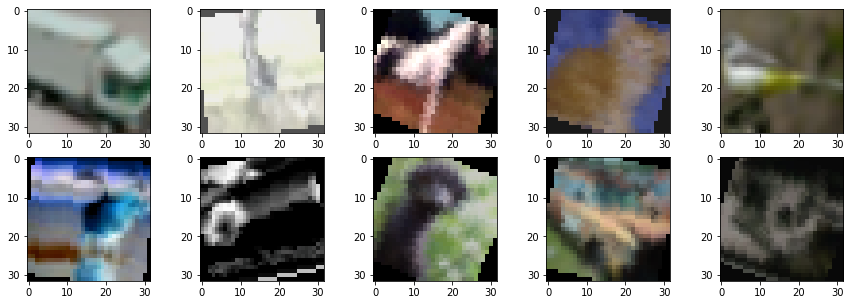

In [20]:
iter_images = iter(augmented_train)
images, _ = next(iter_images)
plt.figure(figsize=[15,5])
for i, image in enumerate(images[:]):
    plt.subplot(2, 5, i+1)
    plt.imshow((torchvision.transforms.ToPILImage()(
        image * torch.Tensor([0.229, 0.224, 0.225])[:, None, None] 
        + torch.Tensor([0.485, 0.456, 0.406])[:, None, None]))
    )

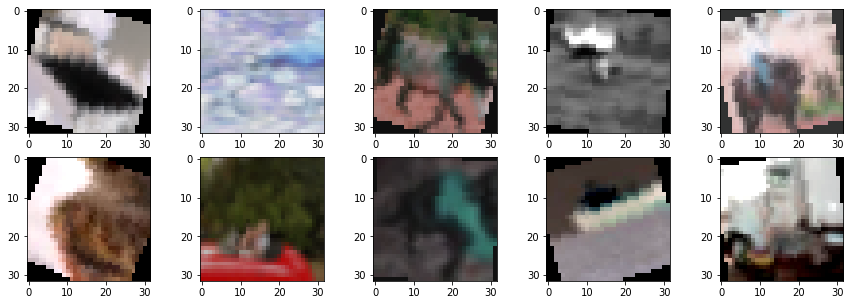

In [21]:
images, _ = next(iter_images)
plt.figure(figsize=[15,5])
for i, image in enumerate(images[:]):
    plt.subplot(2, 5, i+1)
    plt.imshow((torchvision.transforms.ToPILImage()(
        image * torch.Tensor([0.229, 0.224, 0.225])[:, None, None] 
        + torch.Tensor([0.485, 0.456, 0.406])[:, None, None]))
    )

#### Data augmentation + Resnet-18 from scratch

100%|██████████| 10/10 [00:00<00:00, 20.47it/s]


Epoch 1 | Train loss: 2.4321958303451536 | Train acc: 0.14


100%|██████████| 10/10 [00:00<00:00, 24.28it/s]


Epoch 2 | Train loss: 2.3467824697494506 | Train acc: 0.14


100%|██████████| 10/10 [00:00<00:00, 23.77it/s]


...

100%|██████████| 10/10 [00:00<00:00, 24.03it/s]


Epoch 250 | Train loss: 0.7289374187588692 | Train acc: 0.7900000000000001

##########
Train acuracy:  0.7900000000000001
##########



100%|██████████| 40/40 [00:04<00:00,  8.32it/s]


##########
Test acuracy:  0.30517578125
##########



Text(0.5, 0, 'Epochs')

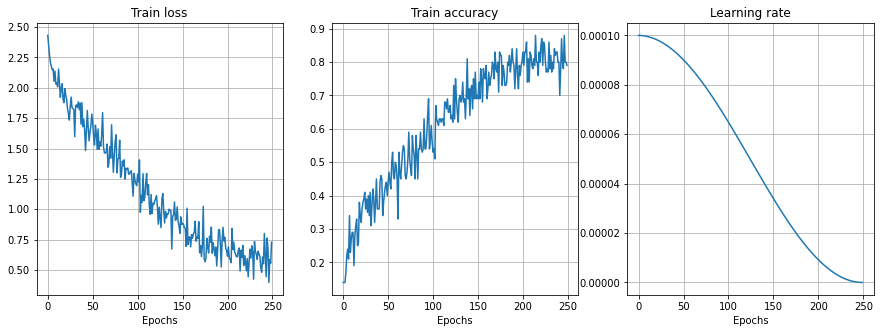

In [22]:
# Training settings
augmented_1 = ResNet18()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(augmented_1.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=250)

# Training 
train_losses, train_accuracies, lrs = train(augmented_1, criterion, optimizer, augmented_train, 250, device, scheduler)
print("\n##########")
print("Train acuracy: ", train_accuracies[-1])
print("##########\n")

# Evaluation
test_loss, test_accuracy = test(augmented_1, criterion, augmented_test, device)
print("\n##########")
print("Test acuracy: ", test_accuracy)
print("##########\n")

# Plots
plt.figure(figsize=[15,5])
plt.subplot(131)
plt.plot(train_losses)
plt.title("Train loss")
plt.grid()
plt.xlabel("Epochs")

plt.subplot(132)
plt.plot(train_accuracies)
plt.title("Train accuracy")
plt.grid()
plt.xlabel("Epochs")

plt.subplot(133)
plt.plot(lrs)
plt.title("Learning rate")
plt.grid()
plt.xlabel("Epochs")

#### Data augmentation + Pretrained Resnet-18

100%|██████████| 10/10 [00:01<00:00,  9.51it/s]


Epoch 1 | Train loss: 2.476124572753906 | Train acc: 0.09000000000000001


100%|██████████| 10/10 [00:01<00:00,  9.82it/s]


Epoch 2 | Train loss: 2.313384175300598 | Train acc: 0.13


100%|██████████| 10/10 [00:00<00:00, 10.34it/s]


...

100%|██████████| 10/10 [00:01<00:00,  9.59it/s]


Epoch 100 | Train loss: 1.4177860736846923 | Train acc: 0.5299999999999999

##########
Train acuracy:  0.5299999999999999
##########



100%|██████████| 40/40 [00:31<00:00,  1.27it/s]


##########
Test acuracy:  0.49072265625
##########



Text(0.5, 0, 'Epochs')

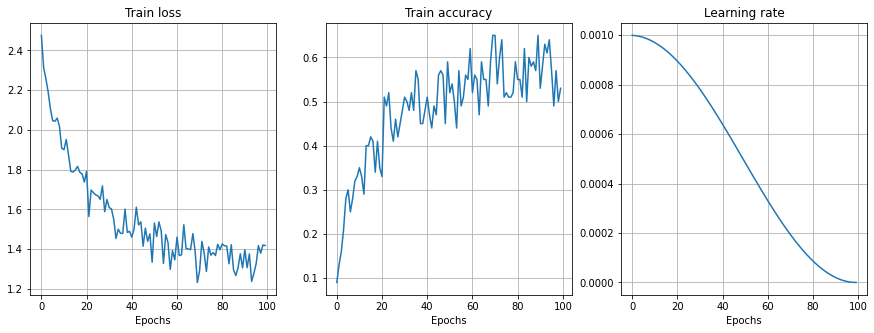

In [77]:
# Model definition
augmented_2 = torchvision.models.resnet18(pretrained=True)
# Freezing the backbone
for param in augmented_2.parameters():
    param.requires_grad = False
# Adapting final layer to predict 10 CIFAR-10 classes
augmented_2.fc = nn.Linear(512, 10)

# Training settings
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(augmented_2.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)

# Training
train_losses, train_accuracies, lrs = train(augmented_2, criterion, optimizer, augmented_train_in, 100, device, scheduler)
print("\n##########")
print("Train acuracy: ", train_accuracies[-1])
print("##########\n")

# Evaluation
test_loss, test_accuracy = test(augmented_2, criterion, augmented_test_in, device)
print("\n##########")
print("Test acuracy: ", test_accuracy)
print("##########\n")

# Plots
plt.figure(figsize=[15,5])
plt.subplot(131)
plt.plot(train_losses)
plt.title("Train loss")
plt.grid()
plt.xlabel("Epochs")

plt.subplot(132)
plt.plot(train_accuracies)
plt.title("Train accuracy")
plt.grid()
plt.xlabel("Epochs")

plt.subplot(133)
plt.plot(lrs)
plt.title("Learning rate")
plt.grid()
plt.xlabel("Epochs")

100%|██████████| 10/10 [00:01<00:00,  7.76it/s]


Epoch 1 | Train loss: 1.2394867241382599 | Train acc: 0.6599999999999999


100%|██████████| 10/10 [00:01<00:00,  7.74it/s]


Epoch 2 | Train loss: 1.3160065293312073 | Train acc: 0.6100000000000001


100%|██████████| 10/10 [00:01<00:00,  7.64it/s]


...

100%|██████████| 10/10 [00:01<00:00,  8.07it/s]


Epoch 100 | Train loss: 0.15873503237962722 | Train acc: 0.96

##########
Train acuracy:  0.96
##########



100%|██████████| 40/40 [00:31<00:00,  1.29it/s]


##########
Test acuracy:  0.57939453125
##########



Text(0.5, 0, 'Epochs')

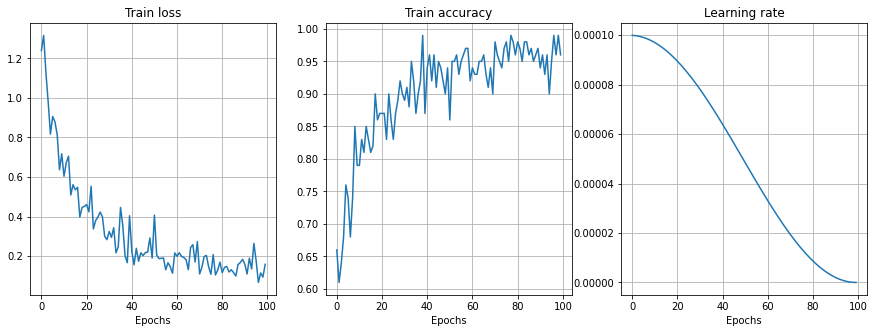

In [78]:
# Unfreeze the backbone
for param in augmented_2.parameters():
    param.requires_grad = True

# Training settings
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(augmented_2.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)

# Training
train_losses, train_accuracies, lrs = train(augmented_2, criterion, optimizer, augmented_train_in, 100, device, scheduler)
print("\n##########")
print("Train acuracy: ", train_accuracies[-1])
print("##########\n")

# Evaluation
test_loss, test_accuracy = test(augmented_2, criterion, augmented_test_in, device)
print("\n##########")
print("Test acuracy: ", test_accuracy)
print("##########\n")

# Plots
plt.figure(figsize=[15,5])
plt.subplot(131)
plt.plot(train_losses)
plt.title("Train loss")
plt.grid()
plt.xlabel("Epochs")

plt.subplot(132)
plt.plot(train_accuracies)
plt.title("Train accuracy")
plt.grid()
plt.xlabel("Epochs")

plt.subplot(133)
plt.plot(lrs)
plt.title("Learning rate")
plt.grid()
plt.xlabel("Epochs")

#### Results

| Model | Number of  epochs  | Train accuracy | Test accuracy |
|------|------|------|------|
|  Data augmentation + Resnet-18 from scratch  | 250 | 0.79 | 0.31 |
|  Data augmentation + pretrained Resnet-18 (linear training) | 100 | 0.53 | 0.49 |
|  Data augmentation + pretrained Resnet-18 (full training) | 200 | 0.96 | 0.58 |


# Conclusions

__Question 7 (5 points) :__ Write a short report explaining the pros and the cons of each method you implemented. 25% of the grade of this project will correspond to this question, thus, it should be done carefully. In particular, please add a plot that will summarize all your numerical results.

**See the attached report**

# Weak supervision

__Bonus \[open\] question (up to 4 points) :__ Pick a weakly supervised method that will potentially use $\mathcal{X}_{\text{nolabel}}\cup\mathcal{X}_{\text{train}}$ to train a model (a subset of $\mathcal{X}_{\text{nolabel}}$ is also fine). Evaluate it and report the accuracies. You should be careful in the choice of your method, in order to avoid heavy computational effort.

**Incremental auto-training**

We'll consider 1000  $\mathcal{X}_{nolabel}^{1000} \subset \mathcal{X}_{nolabel}$. Starting with the best model so far (Pretrained Resnet-18 finetuned on augmented data), we'll train for 100 more epochs, and after each 10 epochs we'll add 100 auto-labeled points (we'll use as targets the predictions of the models). For this final step we won't use data augmentation anymore.

In [83]:
def generate_auto_labels(model, data_loader, n_examples, device):
    """
    Generates predictions for n_examples. Saves the images
    and the labels as expected by PyTorch's ImageFolder dataset.
    Assume that the batch size of the data loader is 10
    """
    # Creating labels dir
    DIR = "data/no-label"
    if os.path.exists(DIR):
        shutil.rmtree(DIR)
    os.makedirs(DIR)
    for i in range(10):
        os.makedirs(os.path.join(DIR, str(i)))
    iterations = n_examples / 10

    for i, data in enumerate(data_loader):
        # Only generating the required predictions
        if i+1 > iterations:
            return
        with torch.no_grad():
            images, _ = data
            model.eval()
            logits = model(images.to(device))
            predictions = logits.argmax(dim=1)
        for j,image in enumerate(images[:]):
            image_to_save = torchvision.transforms.ToPILImage()(
                image * torch.Tensor([0.229, 0.224, 0.225])[:, None, None] 
                + torch.Tensor([0.485, 0.456, 0.406])[:, None, None]
                )
            predicted_label = str(predictions.cpu().numpy()[j])
            image_name = os.path.join(predicted_label, f"{i}_{j}.png")
            image_to_save.save(os.path.join(DIR, image_name))

In [84]:
criterion = nn.CrossEntropyLoss()

# Self-training loop
for i in range(10):
    # Generate new labels
    generate_auto_labels(augmented_2, pretrained_in_size_no_label, 100 * (i+1), device)
    # Expand the dataset
    no_label_dataset = torchvision.datasets.ImageFolder("data/no-label", transform=imagenet_transform_imagenet_size)
    label_dataset = pretrained_in_size_train.dataset
    merged_dataset = torch.utils.data.ConcatDataset([no_label_dataset, label_dataset])
    merged_dataloader = torch.utils.data.DataLoader(merged_dataset, batch_size=10, shuffle=True)
    # Train for 10 more epochs
    optimizer = optim.Adam(pretrained_2.parameters(), lr=1e-4)
    train_losses, train_accuracies, lrs = train(augmented_2, criterion, optimizer, merged_dataloader, 10, device)
    print("\n##########")
    print("Train acuracy: ", train_accuracies[-1])
    print("##########\n")
  
    # Evluate improvement
    test_loss, test_accuracy = test(augmented_2, criterion, pretrained_in_size_test, device)
    print("\n##########")
    print("Test acuracy: ", test_accuracy)
    print("##########\n")

100%|██████████| 20/20 [00:01<00:00, 12.98it/s]


Epoch 1 | Train loss: 0.5070688277482986 | Train acc: 0.845


100%|██████████| 20/20 [00:01<00:00, 14.12it/s]


Epoch 2 | Train loss: 0.5990785261616111 | Train acc: 0.78


100%|██████████| 20/20 [00:01<00:00, 13.99it/s]


...

Epoch 9 | Train loss: 0.6184946729378267 | Train acc: 0.7881818181818182


100%|██████████| 110/110 [00:08<00:00, 13.08it/s]


Epoch 10 | Train loss: 0.5999896610325033 | Train acc: 0.7900000000000003

##########
Train acuracy:  0.7900000000000003
##########



100%|██████████| 40/40 [00:30<00:00,  1.29it/s]


##########
Test acuracy:  0.5732421875
##########

